# AI DJ: Music Recommendation System Based on User Vibe

Keith Walker  
ITAI 1371 – Final Project  

This project uses machine learning to recommend songs based on a user's preferred music vibe. The model predicts whether a song would be liked based on features such as energy, danceability, valence, and tempo.

## 1. Import Libraries and Load Dataset

This section imports the Python libraries used for the project and loads the Music Info dataset into the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("Music Info.csv")

data.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


## 2. Explore the Dataset

This section checks the size of the dataset, displays the column names, and identifies missing values. This helps me understand what data is available before cleaning it.

In [ ]:
print(data.shape)
print(data.columns.tolist())

(50683, 21)
['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id', 'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


In [ ]:
data.isnull().sum()

,0
track_id,0
name,0
artist,0
spotify_preview_url,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0


## 3. Data Cleaning

Some columns were removed because they were not needed for model training. Columns such as track ID, Spotify preview URL, Spotify ID, genre, and tags were removed so the model could focus on song features.

In [ ]:
data = data.drop(columns=[
    "track_id",
    "spotify_preview_url",
    "spotify_id",
    "genre",
    "tags"
], errors="ignore")

data.head()

,name,artist,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Mr. Brightside,The Killers,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,Wonderwall,Oasis,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,Come as You Are,Nirvana,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,Take Me Out,Franz Ferdinand,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,Creep,Radiohead,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [ ]:
data.duplicated().sum()

np.int64(0)

## 4. Create the Target Column

The dataset did not include real user like/dislike data, so I created a simulated target column called `liked`. Songs with higher energy, danceability, and valence were labeled as songs the user would likely enjoy.

- 1 = liked  
- 0 = not liked

In [ ]:
data["liked"] = (
    (data["energy"] > 0.6) &
    (data["danceability"] > 0.5) &
    (data["valence"] > 0.4)
).astype(int)

data["liked"].value_counts()

,count
liked,
0,38347
1,12336


## 5. Select Features and Target

This section separates the input features from the target label. The input features include song characteristics such as energy, danceability, tempo, loudness, and valence. The target is the `liked` column.

In [ ]:
features = [
    "year",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

X = data[features]
y = data["liked"]

In [ ]:
X.dtypes

,0
year,int64
duration_ms,int64
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64
acousticness,float64
instrumentalness,float64


## 6. Split Data Into Training and Testing Sets

The data was split into training and testing sets using an 80/20 split. The training set was used to train the models, and the testing set was used to evaluate performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40546, 14)
Testing set: (10137, 14)


## 7. Random Forest Model

Random Forest was tested because it can handle complex relationships between song features. It uses multiple decision trees and combines their predictions.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7680
           1       1.00      1.00      1.00      2457

    accuracy                           1.00     10137
   macro avg       1.00      1.00      1.00     10137
weighted avg       1.00      1.00      1.00     10137



## 8. Logistic Regression Model

Logistic Regression was used as a simple baseline model. This helped compare a basic classification model against more complex models.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8758015191871362
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7680
           1       0.78      0.68      0.73      2457

    accuracy                           0.88     10137
   macro avg       0.84      0.81      0.82     10137
weighted avg       0.87      0.88      0.87     10137



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 9. Decision Tree Model

Decision Tree was tested because it is easy to understand and can make predictions based on feature rules.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7680
           1       1.00      1.00      1.00      2457

    accuracy                           1.00     10137
   macro avg       1.00      1.00      1.00     10137
weighted avg       1.00      1.00      1.00     10137



## 10. K-Nearest Neighbors Model

KNN was tested to compare a distance-based model with the other models. It predicts based on nearby similar songs.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7067179638946434
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      7680
           1       0.32      0.19      0.23      2457

    accuracy                           0.71     10137
   macro avg       0.54      0.53      0.53     10137
weighted avg       0.66      0.71      0.68     10137



## 11. Model Comparison

This section compares the accuracy of all four models. Random Forest and Decision Tree performed the best, while Logistic Regression and KNN had lower accuracy.

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy
0,Random Forest,1.000000
1,Logistic Regression,0.875802
2,Decision Tree,1.000000
3,KNN,0.706718


## Results Summary

Random Forest and Decision Tree both achieved the highest accuracy. I selected Random Forest as the final model because it is usually more stable than a single decision tree and is less likely to overfit in real-world use.

One important note is that the `liked` label was created from the same features used to train the model. This helped the model perform very well, but it also means the results are based on a simulated user preference rule instead of real user behavior.

## 12. Generate AI DJ Recommendations

After training the Random Forest model, I used it to predict which songs would be liked. These predicted liked songs were then used as AI DJ recommendations.

In [ ]:
data["predicted_like"] = rf.predict(X)

recommendations = data[data["predicted_like"] == 1]

recommendations[["name", "artist", "year", "energy", "danceability", "valence", "tempo"]].head(20)

,name,artist,year,energy,danceability,valence,tempo
2,Come as You Are,Nirvana,1991,0.826,0.508,0.543,120.012
5,Somebody Told Me,The Killers,2005,0.979,0.508,0.704,138.030
6,Viva la Vida,Coldplay,2013,0.806,0.588,0.520,137.973
12,Feel Good Inc.,Gorillaz,2010,0.720,0.809,0.832,138.556
15,Lithium,Nirvana,1991,0.656,0.678,0.485,123.207
16,Song 2,Blur,2012,0.723,0.676,0.779,129.700
21,Supermassive Black Hole,Muse,2010,0.891,0.667,0.837,120.010
31,Dani California,Red Hot Chili Peppers,2006,0.913,0.556,0.730,96.184
34,Clint Eastwood,Gorillaz,2012,0.712,0.659,0.556,167.948
39,Losing My Religion,R.E.M.,2014,0.736,0.668,0.629,126.978


## 13. Sort Recommendations by Vibe

The recommended songs were sorted by energy, danceability, and valence to create a stronger “vibe-based” playlist.

In [ ]:
recommendations = recommendations.sort_values(
    by=["energy", "danceability", "valence"],
    ascending=False
)

recommendations[["name", "artist", "year", "energy", "danceability", "valence", "tempo"]].head(20)

,name,artist,year,energy,danceability,valence,tempo
39192,Einstein-Rosen Bridge,Venetian Snares,2003,1.000,0.654,0.426,163.983
29071,Freaky Friday,Aqua,2009,0.999,0.669,0.674,138.043
44782,Breach,Black Sun Empire,2006,0.999,0.618,0.699,174.002
29254,Ravers Fantasy,Tune Up!,2013,0.999,0.564,0.414,145.716
48844,"Kill, Inc., Motherfuckers",Amduscia,2008,0.999,0.557,0.530,136.000
29274,Drive X-Treme,Ziggy x,2006,0.999,0.555,0.967,142.011
28775,Professional Party People,Basshunter,2006,0.999,0.526,0.582,142.039
41162,Pay the Bill,Clawfinger,1995,0.998,0.590,0.525,95.949
17144,Hotride,The Prodigy,2004,0.998,0.528,0.590,153.013
48713,Fed Up,Hocico,2008,0.998,0.522,0.461,135.794


## 14. Vibe Score

A vibe score was created by averaging energy, danceability, and valence. This gave each recommended song a simple score for how well it matched the AI DJ vibe.

In [ ]:
data["vibe_score"] = (
    data["energy"] +
    data["danceability"] +
    data["valence"]
) / 3

dj_recommendations = data[data["predicted_like"] == 1].sort_values(
    by="vibe_score",
    ascending=False
)

dj_recommendations[["name", "artist", "vibe_score", "energy", "danceability", "valence"]].head(20)

,name,artist,vibe_score,energy,danceability,valence
6202,Wind It Up,Gwen Stefani,0.937000,0.900,0.961,0.950
32910,Beat Again,JLS,0.930333,0.930,0.893,0.968
17110,She's Good For Business,MSTRKRFT,0.929667,0.936,0.910,0.943
42938,Witch Doctor,Cartoons,0.928000,0.941,0.875,0.968
17270,Boogie Shoes,KC and The Sunshine Band,0.927667,0.883,0.935,0.965
27718,Knowing,OutKast,0.924667,0.971,0.875,0.928
41540,Cha Cha Cha,Mo' Horizons,0.923000,0.899,0.955,0.915
21469,Tell Everybody,Róisín Murphy,0.922667,0.842,0.957,0.969
6102,Barbie Girl,Aqua,0.919333,0.978,0.818,0.962
10794,Picture Book,The Kinks,0.918000,0.954,0.830,0.970


## 15. Model Accuracy Visualization

This chart compares the accuracy of the four models tested in the project.

In [ ]:
import matplotlib.pyplot as plt

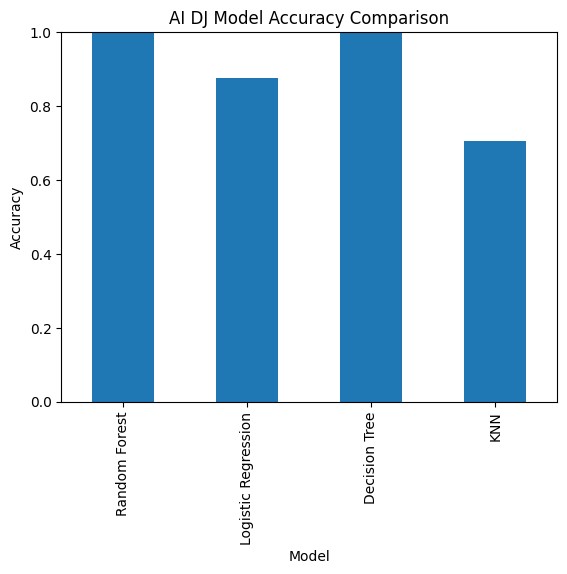

In [ ]:
results.plot(kind="bar", x="Model", y="Accuracy", legend=False)

plt.title("AI DJ Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Random Forest Confusion Matrix

The confusion matrix shows how well the Random Forest model classified liked and not liked songs.

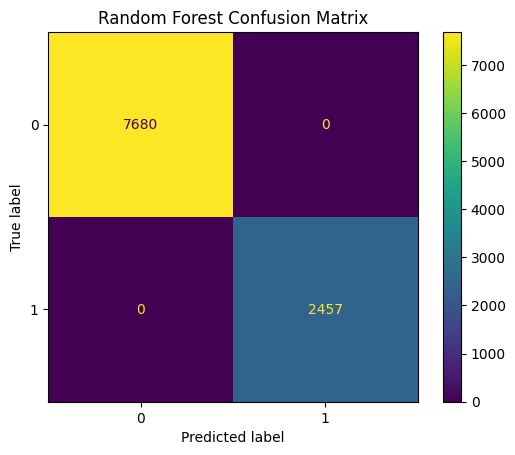

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

## Feature Importance

This chart shows which song features were most important to the Random Forest model.

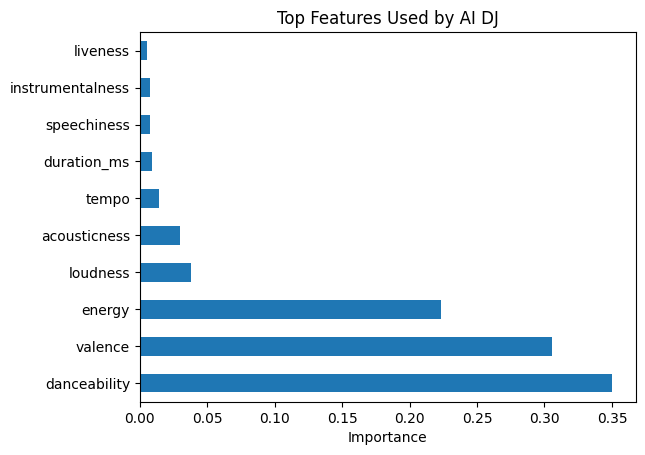

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10).plot(kind="barh")

plt.title("Top Features Used by AI DJ")
plt.xlabel("Importance")
plt.show()

## 16. Discussion

The AI DJ model was able to recommend songs based on audio features like energy, danceability, and valence. Random Forest performed very well and was selected as the final model.

One challenge was that the dataset did not include real user likes or skips, so I had to create a simulated `liked` column. Because of this, the model is learning a rule-based version of user preference instead of actual listener behavior.

## 17. Conclusion

This project showed how machine learning can be used to build a simple AI DJ recommendation system. I learned how to clean a music dataset, create a target column, train multiple models, compare results, and generate song recommendations.

In the future, this project could be improved by using real user listening data, such as likes, skips, playlists, and replay history.